2026-05-27 22:29:18.024682: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


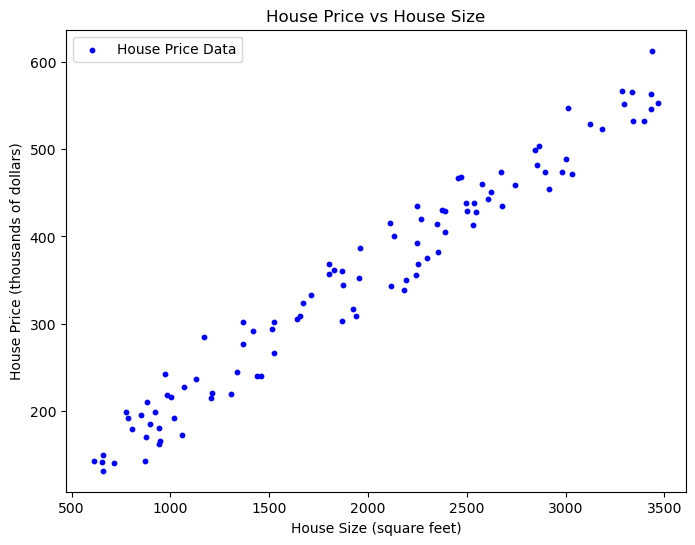

In [1]:
# Implementation using TensorFlow
 
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
 
# Set seeds for reproducibility
tf.random.set_seed(0)
np.random.seed(0)
 
# Generate synthetic dataset
# x_data: house size in square feet
# y_data: house price in thousands of dollars
x_data = np.random.uniform(600, 3500, 100)
noise = np.random.normal(0, 25, 100)
 
# Price formula
y_data = 0.15 * x_data + 50 + noise
 
# Convert to NumPy arrays
x_data = np.array(x_data, dtype=np.float32)
y_data = np.array(y_data, dtype=np.float32)
 
# Scale both input and output data
x_mean, x_std = x_data.mean(), x_data.std()
y_mean, y_std = y_data.mean(), y_data.std()
 
x_scaled = (x_data - x_mean) / x_std
y_scaled = (y_data - y_mean) / y_std
 
# Reshape for TensorFlow
x_train = x_scaled.reshape(-1, 1)
y_train = y_scaled.reshape(-1, 1)
 
# Plot original data
plt.figure(figsize=(8, 6))
plt.scatter(x_data, y_data, color="blue", s=10, label="House Price Data")
plt.xlabel("House Size (square feet)")
plt.ylabel("House Price (thousands of dollars)")
plt.title("House Price vs House Size")
plt.legend()
plt.show()


In [ ]:
# Define the ANN regression model
model = tf.keras.Sequential([
    tf.keras.layers.Dense(8, input_shape=(1,)),
    tf.keras.layers.LeakyReLU(alpha=0.01),
    tf.keras.layers.Dense(1)
])
 
print(model.summary())
 
# Compile the model with MSE loss and Adam optimizer
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.01),
    loss="mse"
)
 
# Train the model
history = model.fit(x_train, y_train, epochs=2000, verbose=0)
 
# Print loss every 200 epochs
for epoch in range(0, 2000, 200):
    print(f"Epoch {epoch + 1}, Loss: {history.history['loss'][epoch]:.4f}")
 
# Plot training loss
plt.figure(figsize=(8, 6))
plt.plot(history.history["loss"], label="Training Loss")
plt.xlabel("Epochs")
plt.ylabel("MSE Loss")
plt.title("Loss Curve During Training")
plt.legend()
plt.show()


/opt/anaconda3/lib/python3.12/site-packages/keras/src/layers/core/dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
/opt/anaconda3/lib/python3.12/site-packages/keras/src/layers/activations/leaky_relu.py:41: UserWarning: Argument `alpha` is deprecated. Use `negative_slope` instead.
  warnings.warn(


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 8)              │            16 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu (LeakyReLU)         │ (None, 8)              │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │             9 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 25 (100.00 B)

 Trainable params: 25 (100.00 B)

 Non-trainable params: 0 (0.00 B)

None


In [ ]:
# Generate predictions
predictions_scaled = model.predict(x_train)
predictions = predictions_scaled * y_std + y_mean
 
# Sort values for a cleaner prediction line
sorted_indices = np.argsort(x_data)
x_sorted = x_data[sorted_indices]
y_sorted = y_data[sorted_indices]
predictions_sorted = predictions.flatten()[sorted_indices]
 
# Plot actual data and model predictions
plt.figure(figsize=(8, 6))
plt.scatter(x_data, y_data, color="blue", s=10, label="Actual Data")
plt.plot(x_sorted, predictions_sorted, color="red", label="Model Prediction")
plt.xlabel("House Size (square feet)")
plt.ylabel("House Price (thousands of dollars)")
plt.title("Model Fit: ANN Prediction of House Prices")
plt.legend()
plt.show()
